# 🏠 Análise de Preços de Casas nos Estados Unidos
## Data Analysis & Machine Learning Hackathon — FAESA Centro Universitário
**Prof. Howard Roatti | C3 Avaliação**
**INTEGRANTES:**
- Eduardo Rodrigues Rangel Malaquias
- Juliano De Andrade Dantas Rodrigues
- Júlia Soares Gomes Paiva

---
Este notebook apresenta uma análise completa do dataset de preços de casas, cobrindo:
1. Análise Exploratória de Dados (EDA) e Feature Engineering
2. Aprendizagem Supervisionada: Regressão
3. Aprendizagem Supervisionada: Classificação
4. Aprendizagem Não Supervisionada: Clusterização, Redução de Dimensionalidade, Associação e Outlier
5. Métricas de Avaliação e Comparação


---
## 0. Imports e Configurações

In [1]:
# ── Core ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Sklearn ───────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Regressão
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

# Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Métricas
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)

# Não-supervisionado
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import LocalOutlierFactor

# XGBoost
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost não instalado; será ignorado.')

# MLxtend (Apriori)
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    HAS_MLX = True
except ImportError:
    HAS_MLX = False
    print('mlxtend não instalado; Apriori será ignorado.')

# ── Estilo ───────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette('muted')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (10, 5)})

SEED = 42
np.random.seed(SEED)
print('✅ Imports OK')

✅ Imports OK


---
## 1. Análise Exploratória de Dados (EDA) e Feature Engineering

In [2]:
# ── Carregamento ──────────────────────────────────────────────────────
df = pd.read_csv('data/train.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1460, 27)


,Id,MSSubClass,MSZoning,LotArea,LotShape,Neighborhood,BldgType,HouseStyle,OverallQual,OverallCond,...,FullBath,HalfBath,BedroomAbvGr,GrLivArea,Fireplaces,GarageType,GarageCars,GarageArea,PoolArea,SalePrice
0,1,75,RM,10387,Reg,SawyerW,1Fam,2.5Unf,10,1,...,0,2,5,1310,2,BuiltIn,1,284.0,0,255371
1,2,50,RL,7561,Reg,CollgCr,1Fam,1Story,4,2,...,0,1,3,1716,0,Detchd,2,498.0,0,242539
2,3,75,RH,11201,Reg,Sawyer,1Fam,1Story,10,7,...,1,2,4,2825,0,Attchd,1,216.0,0,351204
3,4,70,FV,17352,IR1,Edwards,1Fam,1Story,8,6,...,1,1,3,1163,0,NaN,3,825.0,0,235859
4,5,120,RL,7207,Reg,NWAmes,1Fam,2Story,9,6,...,0,0,3,2823,0,Detchd,0,0.0,0,299873


In [3]:
# ── Tipos e Valores Faltantes ─────────────────────────────────────────
print('=== Tipos de variáveis ===')
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Numéricas ({len(numeric_cols)}): {numeric_cols}')
print(f'Categóricas ({len(cat_cols)}): {cat_cols}')

print('\n=== Valores Faltantes ===')
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing if not missing.empty else 'Nenhum após imputação.')

print('\n=== Estatísticas Descritivas ===')
df.describe().round(2)

=== Tipos de variáveis ===
Numéricas (18): ['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'TotalBsmtSF', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'GrLivArea', 'Fireplaces', 'GarageCars', 'GarageArea', 'PoolArea', 'SalePrice']
Categóricas (9): ['MSZoning', 'LotShape', 'Neighborhood', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'HeatingQC', 'GarageType']

=== Valores Faltantes ===
MasVnrArea      8
TotalBsmtSF     5
GarageType     78
GarageArea      5
dtype: int64

=== Estatísticas Descritivas ===


/tmp/ipykernel_665/2277455391.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


,Id,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,GrLivArea,Fireplaces,GarageCars,GarageArea,PoolArea,SalePrice
count,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1452.00,1455.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1455.00,1460.00,1460.00
mean,730.50,93.11,9373.55,5.54,5.06,1953.77,1967.03,83.13,945.13,1.51,0.47,2.55,1888.32,0.64,1.52,333.56,2.23,246216.22
std,421.61,53.13,5008.38,2.89,2.59,31.62,30.75,132.04,446.47,1.10,0.59,1.67,576.87,0.69,1.10,251.79,34.27,53698.57
min,1.00,20.00,1602.00,1.00,1.00,1900.00,1900.00,0.00,0.00,0.00,0.00,0.00,684.00,0.00,0.00,0.00,0.00,89864.00
25%,365.75,50.00,5925.00,3.00,3.00,1927.00,1942.00,0.00,658.00,1.00,0.00,1.00,1487.00,0.00,1.00,162.50,0.00,207630.50
50%,730.50,80.00,8309.50,6.00,5.00,1953.00,1967.00,0.00,884.00,1.00,0.00,3.00,1794.50,1.00,2.00,303.00,0.00,244652.00
75%,1095.25,150.00,11358.50,8.00,7.00,1981.25,1996.00,100.00,1168.00,2.00,1.00,4.00,2210.25,1.00,2.00,531.50,0.00,280968.25
max,1460.00,190.00,55623.00,10.00,9.00,2009.00,2010.00,500.00,3722.00,3.00,2.00,5.00,5417.00,3.00,3.00,1009.00,788.00,449756.00


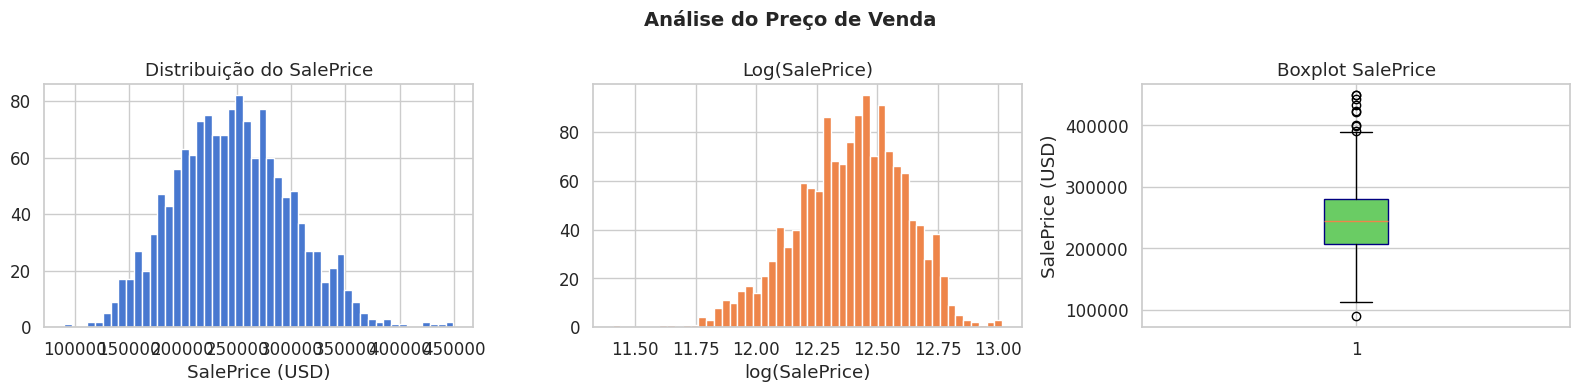

In [4]:
# ── Distribuição do Preço de Venda ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['SalePrice'], bins=50, color=COLORS[0], edgecolor='white')
axes[0].set_title('Distribuição do SalePrice')
axes[0].set_xlabel('SalePrice (USD)')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color=COLORS[1], edgecolor='white')
axes[1].set_title('Log(SalePrice)')
axes[1].set_xlabel('log(SalePrice)')

axes[2].boxplot(df['SalePrice'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=COLORS[2], color='navy'))
axes[2].set_title('Boxplot SalePrice')
axes[2].set_ylabel('SalePrice (USD)')

plt.suptitle('Análise do Preço de Venda', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/01_saleprice_distribution.png', bbox_inches='tight')
plt.show()

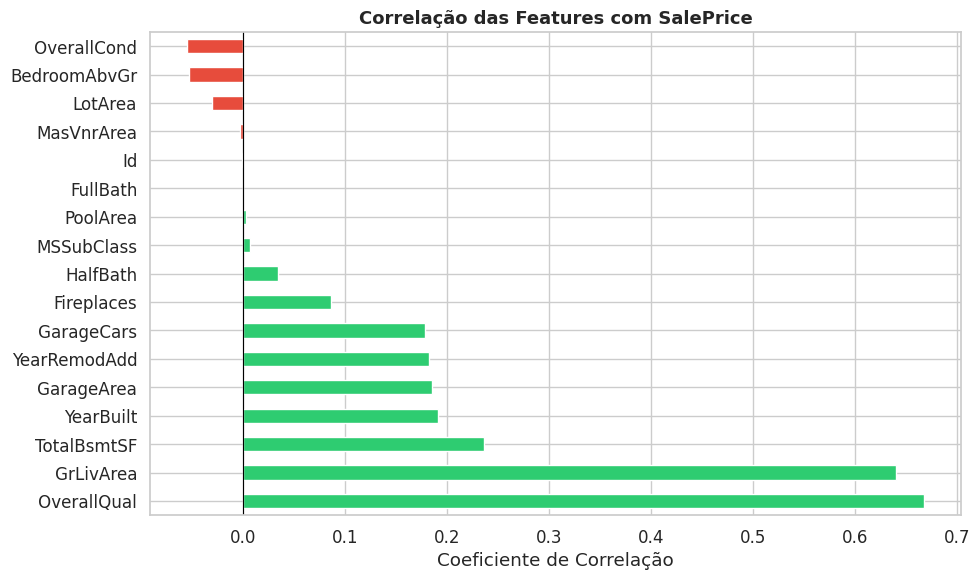

OverallQual     0.667611
GrLivArea       0.640378
TotalBsmtSF     0.236371
YearBuilt       0.190583
GarageArea      0.185131
YearRemodAdd    0.181516
GarageCars      0.178482
Fireplaces      0.086109
HalfBath        0.034091
MSSubClass      0.006683
PoolArea        0.002177
FullBath       -0.000873
Id             -0.001555
MasVnrArea     -0.003839
LotArea        -0.030537
BedroomAbvGr   -0.053933
OverallCond    -0.055147
Name: SalePrice, dtype: float64


In [5]:
# ── Correlações com SalePrice ─────────────────────────────────────────
num_df = df[numeric_cols].dropna()
corr = num_df.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in corr.values]
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Correlação das Features com SalePrice', fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente de Correlação')
plt.tight_layout()
plt.savefig('plots/02_correlation_saleprice.png', bbox_inches='tight')
plt.show()
print(corr)

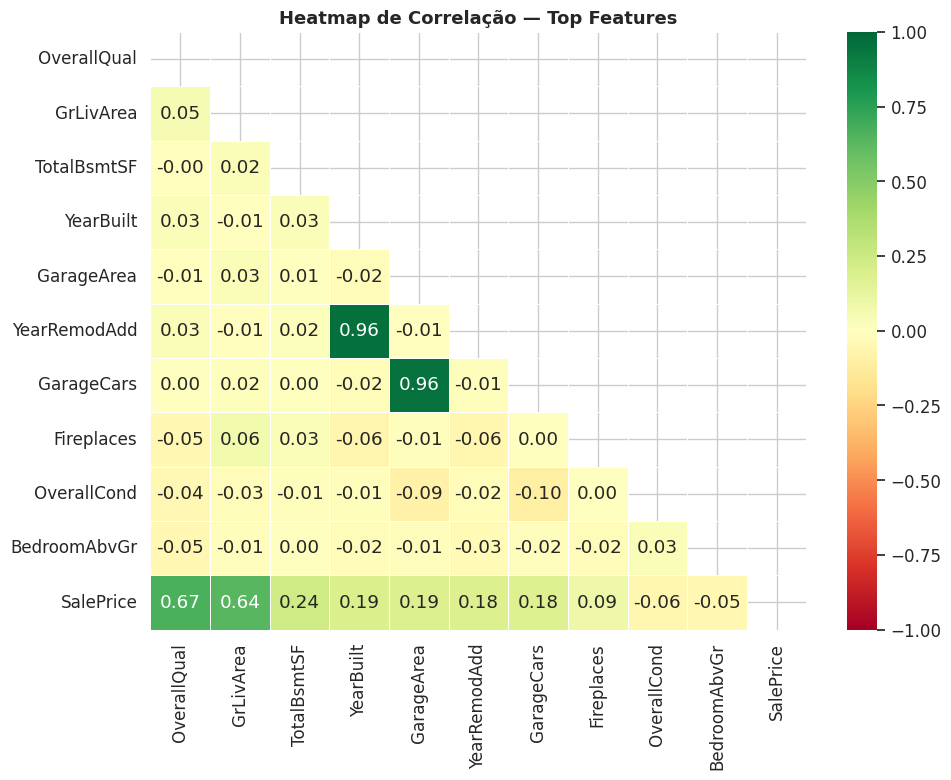

In [6]:
# ── Heatmap de Correlações ────────────────────────────────────────────
top_corr_cols = corr.abs().nlargest(10).index.tolist() + ['SalePrice']
corr_matrix = num_df[top_corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Heatmap de Correlação — Top Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_heatmap_correlation.png', bbox_inches='tight')
plt.show()

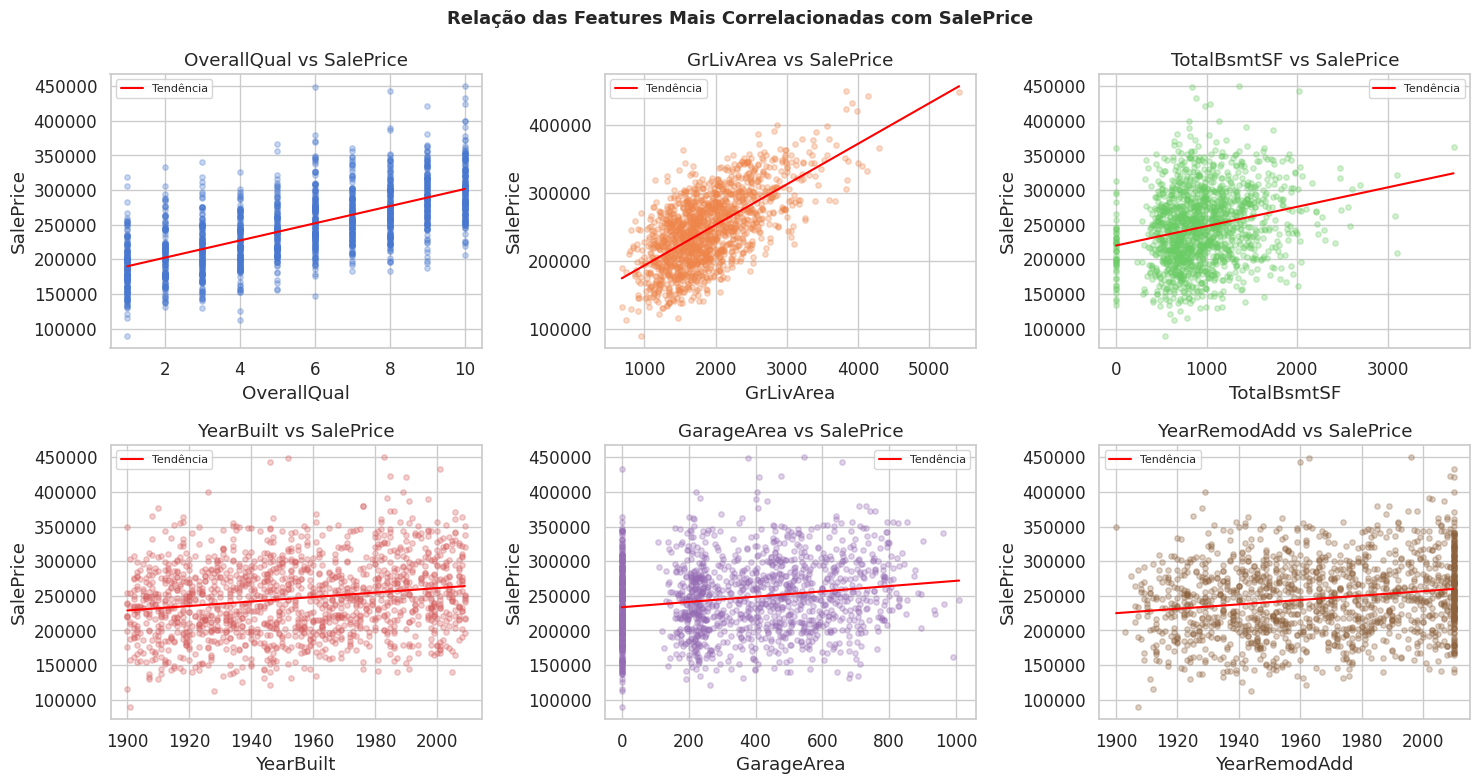

In [7]:
# ── Scatter plots das top features ───────────────────────────────────
top_num = corr.abs().nlargest(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_num):
    axes[i].scatter(df[col], df['SalePrice'], alpha=0.3, s=15, color=COLORS[i % len(COLORS)])
    m, b = np.polyfit(df[col].fillna(0), df['SalePrice'], 1)
    xline = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(xline, m*xline + b, color='red', lw=1.5, label='Tendência')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{col} vs SalePrice')
    axes[i].legend(fontsize=8)

plt.suptitle('Relação das Features Mais Correlacionadas com SalePrice', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_scatter_top_features.png', bbox_inches='tight')
plt.show()

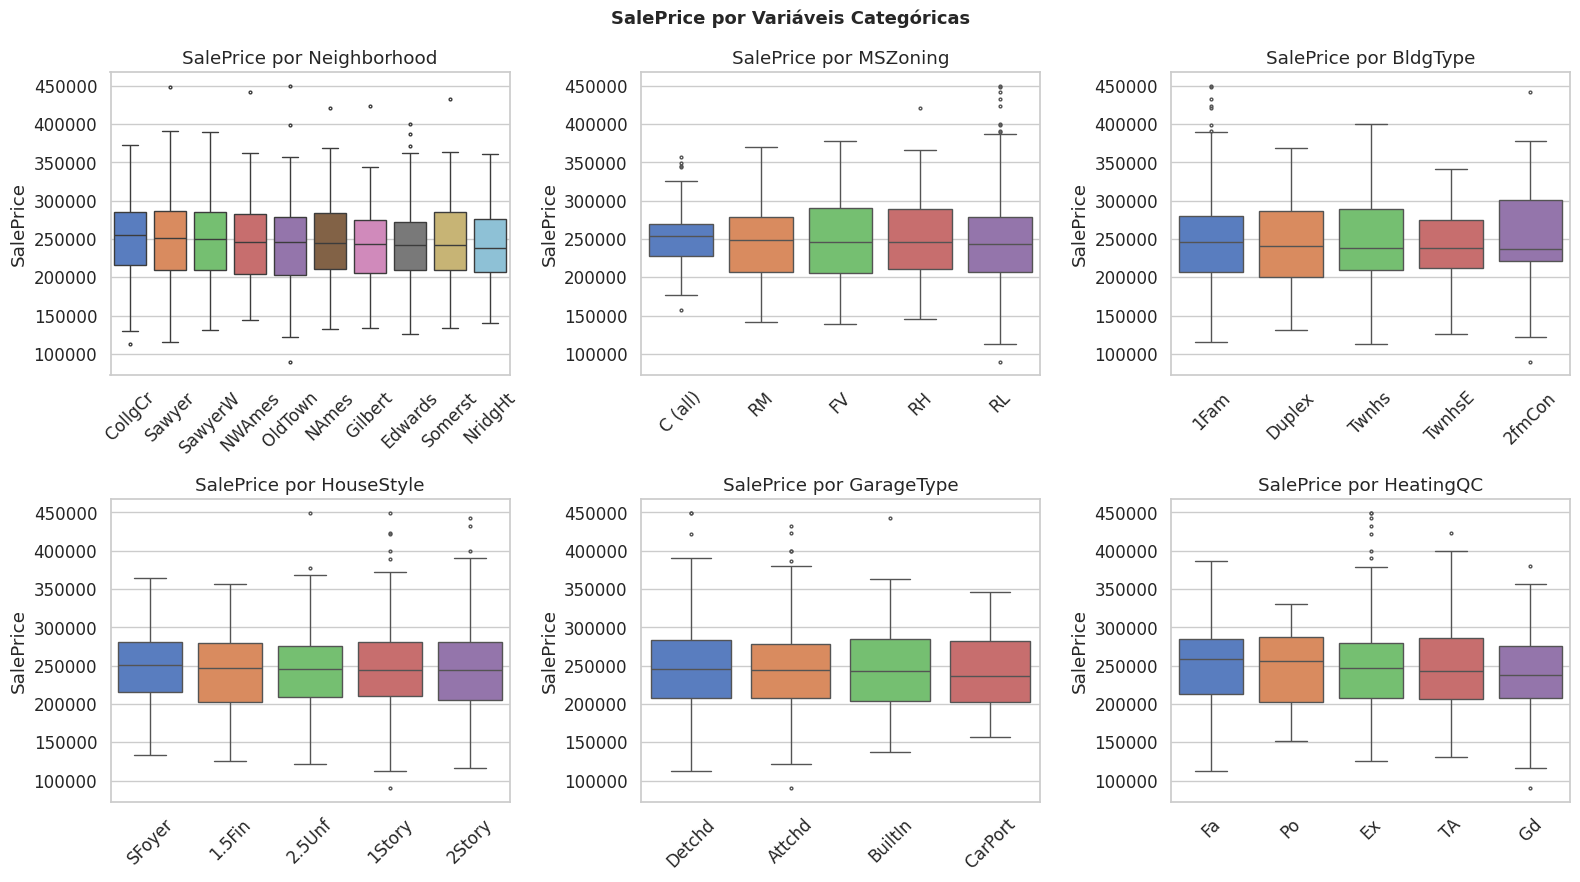

In [8]:
# ── Variáveis Categóricas ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

cat_to_plot = ['Neighborhood', 'MSZoning', 'BldgType', 'HouseStyle', 'GarageType', 'HeatingQC']
for i, col in enumerate(cat_to_plot):
    order = df.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='SalePrice', order=order, ax=axes[i],
                palette='muted', flierprops=dict(marker='.', markersize=4))
    axes[i].set_title(f'SalePrice por {col}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.suptitle('SalePrice por Variáveis Categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_categorical_boxplots.png', bbox_inches='tight')
plt.show()

In [9]:
# ══════════════════════════════════════════════════════════════════════
#  FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════

df_fe = df.copy()

# 1. Imputação de valores faltantes
num_imp_cols = ['MasVnrArea', 'TotalBsmtSF', 'GarageArea']
for c in num_imp_cols:
    df_fe[c] = df_fe[c].fillna(df_fe[c].median())

# 2. Novas features
df_fe['HouseAge']      = 2010 - df_fe['YearBuilt']
df_fe['RemodAge']      = 2010 - df_fe['YearRemodAdd']
df_fe['TotalSF']       = df_fe['GrLivArea'] + df_fe['TotalBsmtSF']
df_fe['TotalBath']     = df_fe['FullBath'] + 0.5 * df_fe['HalfBath']
df_fe['QualArea']      = df_fe['OverallQual'] * df_fe['GrLivArea']
df_fe['HasPool']       = (df_fe['PoolArea'] > 0).astype(int)
df_fe['HasFireplace']  = (df_fe['Fireplaces'] > 0).astype(int)
df_fe['HasGarage']     = (df_fe['GarageCars'] > 0).astype(int)

# 3. Transformação log no target
df_fe['LogSalePrice']  = np.log1p(df_fe['SalePrice'])

# 4. Codificação de variáveis categóricas (Label Encoding)
le = LabelEncoder()
for col in cat_cols:
    df_fe[col + '_enc'] = le.fit_transform(df_fe[col].astype(str))

print('✅ Feature Engineering concluído')
print(f'Shape antes: {df.shape} → depois: {df_fe.shape}')
print('Novas features criadas:', ['HouseAge','RemodAge','TotalSF','TotalBath',
                                   'QualArea','HasPool','HasFireplace','HasGarage','LogSalePrice'])

✅ Feature Engineering concluído
Shape antes: (1460, 27) → depois: (1460, 45)
Novas features criadas: ['HouseAge', 'RemodAge', 'TotalSF', 'TotalBath', 'QualArea', 'HasPool', 'HasFireplace', 'HasGarage', 'LogSalePrice']


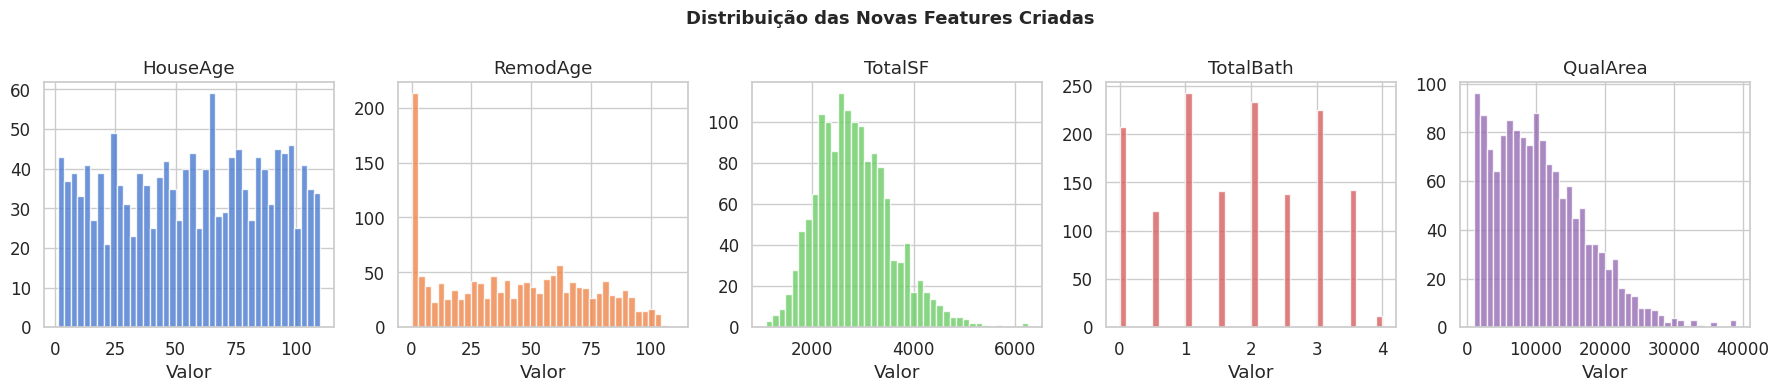

In [10]:
# ── Distribuições das novas features ──────────────────────────────────
new_feats = ['HouseAge', 'RemodAge', 'TotalSF', 'TotalBath', 'QualArea']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(new_feats):
    axes[i].hist(df_fe[col], bins=40, color=COLORS[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
plt.suptitle('Distribuição das Novas Features Criadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_new_features_distribution.png', bbox_inches='tight')
plt.show()

---
## 2. Aprendizagem Supervisionada — Regressão

In [11]:
# ── Preparação dos dados para Regressão ──────────────────────────────
feature_cols = [
    'OverallQual', 'OverallCond', 'GrLivArea', 'TotalBsmtSF', 'GarageArea',
    'LotArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'GarageCars',
    'Fireplaces', 'PoolArea', 'MasVnrArea', 'MSSubClass',
    'HouseAge', 'RemodAge', 'TotalSF', 'TotalBath', 'QualArea',
    'HasPool', 'HasFireplace', 'HasGarage',
    'MSZoning_enc', 'Neighborhood_enc', 'BldgType_enc',
    'HouseStyle_enc', 'GarageType_enc', 'HeatingQC_enc'
]

X = df_fe[feature_cols]
y = df_fe['LogSalePrice']      # target em log
y_orig = df_fe['SalePrice']   # target original (para métricas)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
_, _, yorig_train, yorig_test = train_test_split(X, y_orig, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (1168, 28) | Test: (292, 28)


In [12]:
# ── Treinamento dos Modelos de Regressão ──────────────────────────────
regressors = {
    'Regressão Linear':        LinearRegression(),
    'Ridge':                   Ridge(alpha=1.0, random_state=SEED),
    'Lasso':                   Lasso(alpha=0.001, random_state=SEED),
    'KNN Regressor':           KNeighborsRegressor(n_neighbors=7),
    'Árvore de Decisão':       DecisionTreeRegressor(max_depth=8, random_state=SEED),
    'Random Forest':           RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED),
    'Gradient Boosting':       GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=SEED),
}
if HAS_XGB:
    regressors['XGBoost'] = xgb.XGBRegressor(n_estimators=100, max_depth=5,
                                               learning_rate=0.1, random_state=SEED, verbosity=0)

reg_results = []
reg_predictions = {}

for name, model in regressors.items():
    model.fit(X_train_sc, y_train)
    y_pred_log = model.predict(X_test_sc)
    y_pred = np.expm1(y_pred_log)          # voltar à escala original

    mae  = mean_absolute_error(yorig_test, y_pred)
    rmse = np.sqrt(mean_squared_error(yorig_test, y_pred))
    r2   = r2_score(yorig_test, y_pred)
    cv   = cross_val_score(model, X_train_sc, y_train, cv=5,
                            scoring='neg_root_mean_squared_error').mean()

    reg_results.append({'Modelo': name, 'MAE': mae, 'RMSE': rmse,
                        'R²': r2, 'CV-RMSE (log)': -cv})
    reg_predictions[name] = y_pred
    print(f'{name:25s} | MAE={mae:>8,.0f} | RMSE={rmse:>9,.0f} | R²={r2:.4f}')

reg_df = pd.DataFrame(reg_results).sort_values('R²', ascending=False).reset_index(drop=True)
reg_df

Regressão Linear          | MAE=  13,652 | RMSE=   17,338 | R²=0.8723
Ridge                     | MAE=  13,601 | RMSE=   17,252 | R²=0.8736
Lasso                     | MAE=  13,329 | RMSE=   16,778 | R²=0.8804
KNN Regressor             | MAE=  20,857 | RMSE=   26,044 | R²=0.7119
Árvore de Decisão         | MAE=  19,157 | RMSE=   24,861 | R²=0.7375


Random Forest             | MAE=  14,480 | RMSE=   18,174 | R²=0.8597


Gradient Boosting         | MAE=  13,873 | RMSE=   17,615 | R²=0.8682


XGBoost                   | MAE=  14,023 | RMSE=   17,812 | R²=0.8652


,Modelo,MAE,RMSE,R²,CV-RMSE (log)
0,Lasso,13328.783535,16778.486861,0.880419,0.067635
1,Ridge,13601.281805,17252.123007,0.873572,0.066827
2,Regressão Linear,13652.418619,17338.161282,0.872308,0.066827
3,Gradient Boosting,13873.005337,17614.978553,0.868198,0.075099
4,XGBoost,14023.361328,17811.894453,0.865235,0.075683
5,Random Forest,14479.783067,18174.401224,0.859694,0.078547
6,Árvore de Decisão,19157.139596,24860.703416,0.737467,0.110672
7,KNN Regressor,20857.200263,26044.001761,0.711881,0.121865


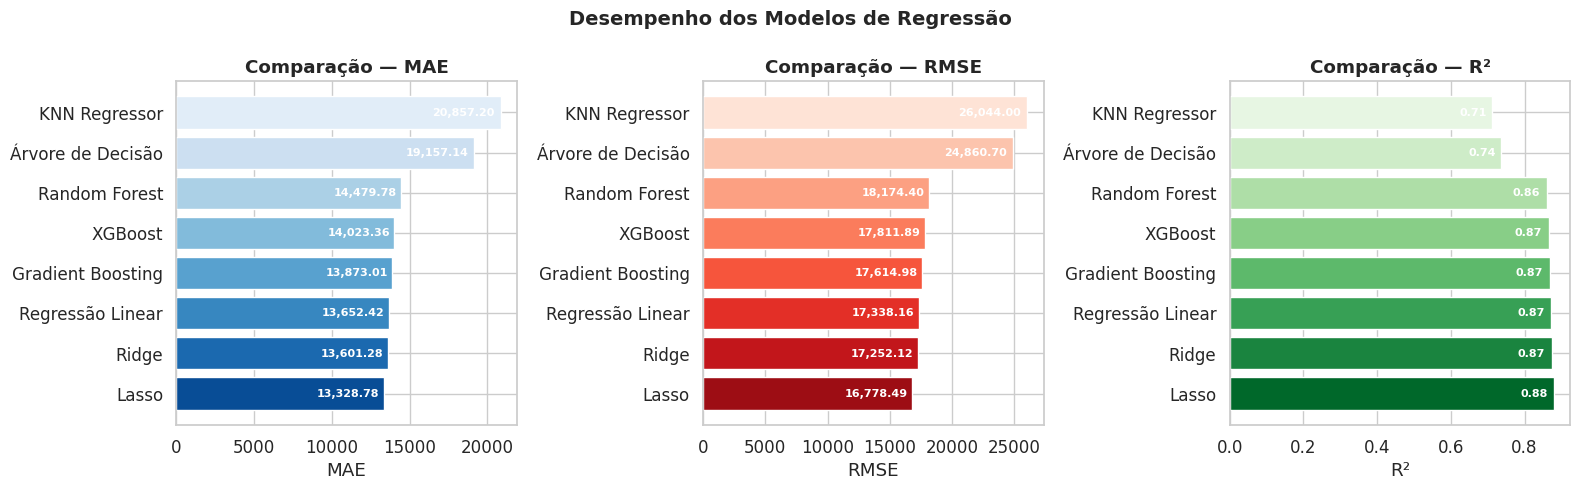

In [13]:
# ── Visualização das Métricas de Regressão ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R²']
palettes = ['Blues_r', 'Reds_r', 'Greens_r']

for ax, m, pal in zip(axes, metrics, palettes):
    data = reg_df.sort_values(m, ascending=(m != 'R²'))
    bars = ax.barh(data['Modelo'], data[m],
                   color=sns.color_palette(pal, len(data)))
    ax.set_title(f'Comparação — {m}', fontweight='bold')
    ax.set_xlabel(m)
    for bar, val in zip(bars, data[m]):
        ax.text(bar.get_width() * 0.98, bar.get_y() + bar.get_height()/2,
                f'{val:,.2f}', va='center', ha='right', fontsize=8, color='white', fontweight='bold')

plt.suptitle('Desempenho dos Modelos de Regressão', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/07_regression_metrics.png', bbox_inches='tight')
plt.show()

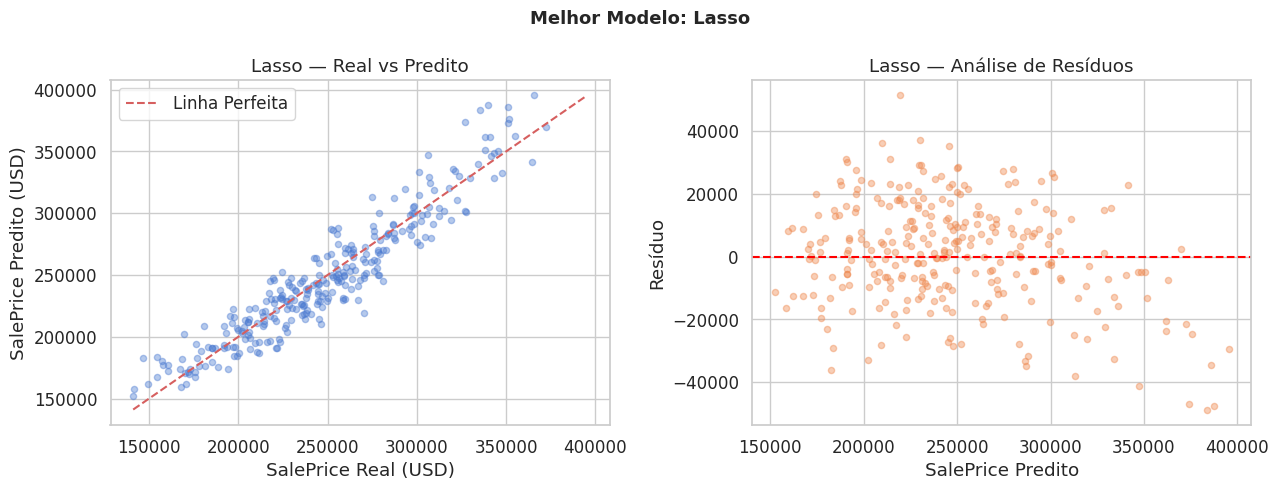

In [14]:
# ── Real vs Predito — Melhor Modelo ──────────────────────────────────
best_reg_name = reg_df.iloc[0]['Modelo']
best_pred = reg_predictions[best_reg_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter real vs predito
axes[0].scatter(yorig_test, best_pred, alpha=0.4, s=20, color=COLORS[0])
mn, mx = min(yorig_test.min(), best_pred.min()), max(yorig_test.max(), best_pred.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Linha Perfeita')
axes[0].set_xlabel('SalePrice Real (USD)')
axes[0].set_ylabel('SalePrice Predito (USD)')
axes[0].set_title(f'{best_reg_name} — Real vs Predito')
axes[0].legend()

# Resíduos
residuals = yorig_test.values - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.4, s=20, color=COLORS[1])
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('SalePrice Predito')
axes[1].set_ylabel('Resíduo')
axes[1].set_title(f'{best_reg_name} — Análise de Resíduos')

plt.suptitle(f'Melhor Modelo: {best_reg_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/08_best_regressor_analysis.png', bbox_inches='tight')
plt.show()

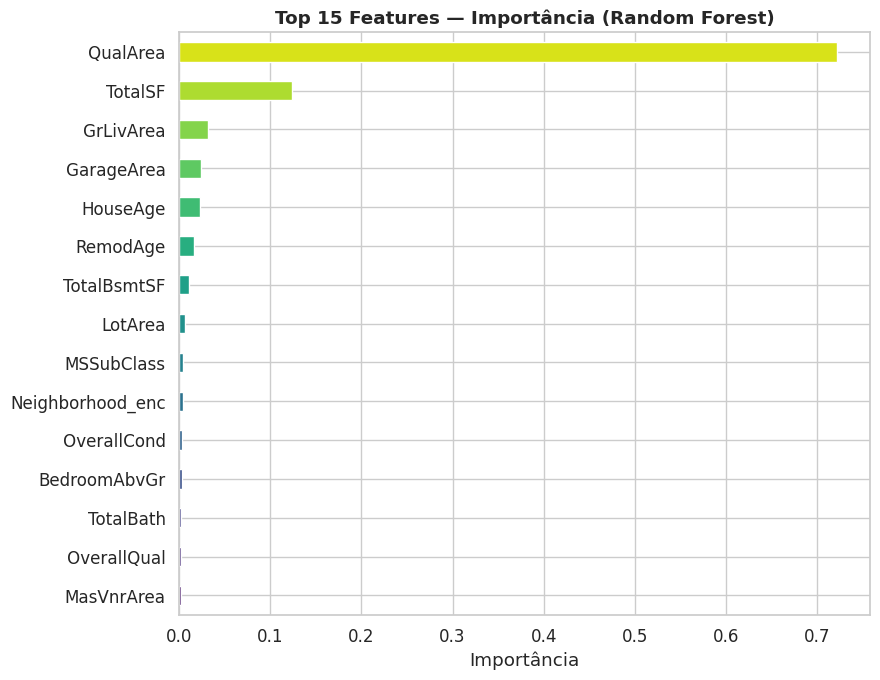

In [15]:
# ── Importância de Features (Random Forest) ───────────────────────────
rf_reg = regressors['Random Forest']
feat_imp = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
feat_imp.tail(15).plot(kind='barh', ax=ax, color=sns.color_palette('viridis', 15))
ax.set_title('Top 15 Features — Importância (Random Forest)', fontweight='bold')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.savefig('plots/09_feature_importance_rf.png', bbox_inches='tight')
plt.show()

---
## 3. Aprendizagem Supervisionada — Classificação

In [16]:
# ── Criar variável binária: Preço Alto / Baixo ────────────────────────
threshold = df_fe['SalePrice'].median()
df_fe['PriceClass'] = (df_fe['SalePrice'] >= threshold).astype(int)
print(f'Threshold (mediana): USD {threshold:,.0f}')
print(df_fe['PriceClass'].value_counts())
print('0 = Preço Baixo | 1 = Preço Alto')

yc = df_fe['PriceClass']
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, yc, test_size=0.2, random_state=SEED, stratify=yc)

Xc_train_sc = scaler.fit_transform(Xc_train)
Xc_test_sc  = scaler.transform(Xc_test)

Threshold (mediana): USD 244,652
PriceClass
1    730
0    730
Name: count, dtype: int64
0 = Preço Baixo | 1 = Preço Alto


In [17]:
# ── Treinamento dos Classificadores ──────────────────────────────────
classifiers = {
    'Regressão Logística':  LogisticRegression(max_iter=1000, random_state=SEED),
    'Naive Bayes':          GaussianNB(),
    'KNN':                  KNeighborsClassifier(n_neighbors=7),
    'Árvore de Decisão':    DecisionTreeClassifier(max_depth=8, random_state=SEED),
    'Random Forest':        RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=SEED),
}
if HAS_XGB:
    classifiers['XGBoost'] = xgb.XGBClassifier(n_estimators=100, max_depth=5,
                                                 learning_rate=0.1, random_state=SEED,
                                                 use_label_encoder=False, eval_metric='logloss')

clf_results = []
clf_probs = {}
clf_preds = {}

for name, model in classifiers.items():
    model.fit(Xc_train_sc, yc_train)
    y_pred = model.predict(Xc_test_sc)
    y_prob = model.predict_proba(Xc_test_sc)[:, 1]

    acc = accuracy_score(yc_test, y_pred)
    auc = roc_auc_score(yc_test, y_prob)
    cv  = cross_val_score(model, Xc_train_sc, yc_train, cv=5, scoring='accuracy').mean()

    clf_results.append({'Modelo': name, 'Acurácia': acc, 'AUC-ROC': auc, 'CV-Acc': cv})
    clf_probs[name] = y_prob
    clf_preds[name] = y_pred
    print(f'{name:25s} | Acc={acc:.4f} | AUC={auc:.4f} | CV={cv:.4f}')

clf_df = pd.DataFrame(clf_results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
clf_df

Regressão Logística       | Acc=0.9110 | AUC=0.9799 | CV=0.9084
Naive Bayes               | Acc=0.9144 | AUC=0.9666 | CV=0.8887
KNN                       | Acc=0.8014 | AUC=0.8960 | CV=0.8091
Árvore de Decisão         | Acc=0.8699 | AUC=0.8366 | CV=0.8424


Random Forest             | Acc=0.8973 | AUC=0.9716 | CV=0.8938


Gradient Boosting         | Acc=0.9178 | AUC=0.9717 | CV=0.8964


XGBoost                   | Acc=0.9178 | AUC=0.9767 | CV=0.9033


,Modelo,Acurácia,AUC-ROC,CV-Acc
0,Regressão Logística,0.910959,0.979921,0.908411
1,XGBoost,0.917808,0.976684,0.903268
2,Gradient Boosting,0.917808,0.971664,0.896401
3,Random Forest,0.897260,0.971618,0.893841
4,Naive Bayes,0.914384,0.966645,0.888705
5,KNN,0.801370,0.896041,0.809097
6,Árvore de Decisão,0.869863,0.836649,0.842423


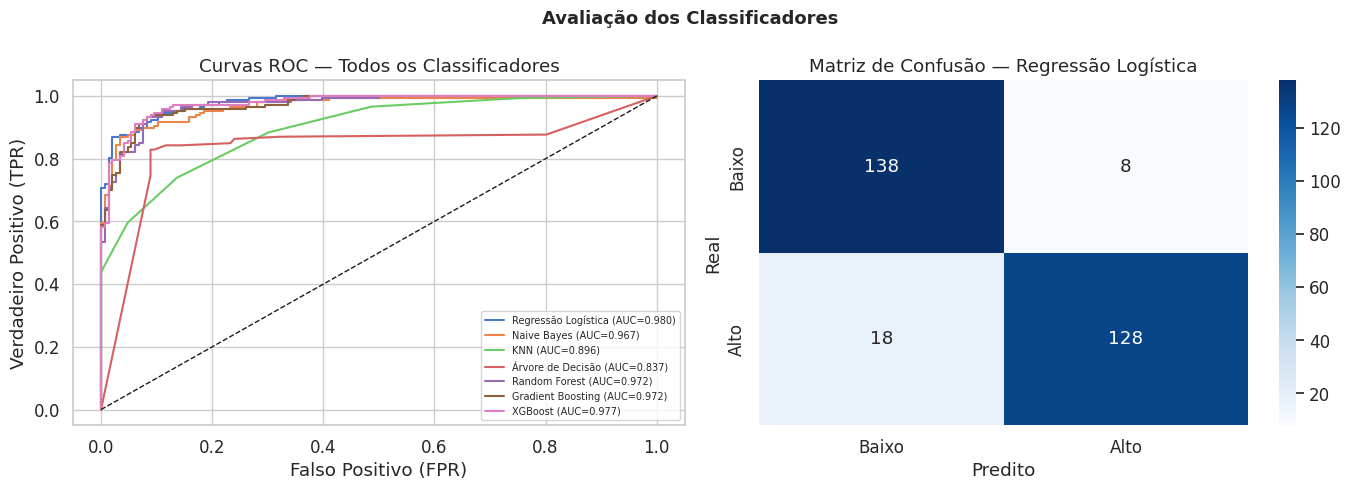


Melhor Classificador: Regressão Logística
              precision    recall  f1-score   support

 Preço Baixo       0.88      0.95      0.91       146
  Preço Alto       0.94      0.88      0.91       146

    accuracy                           0.91       292
   macro avg       0.91      0.91      0.91       292
weighted avg       0.91      0.91      0.91       292



In [18]:
# ── Curvas ROC ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, prob in clf_probs.items():
    fpr, tpr, _ = roc_curve(yc_test, prob)
    auc = roc_auc_score(yc_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', lw=1.5)
axes[0].plot([0,1], [0,1], 'k--', lw=1)
axes[0].set_xlabel('Falso Positivo (FPR)')
axes[0].set_ylabel('Verdadeiro Positivo (TPR)')
axes[0].set_title('Curvas ROC — Todos os Classificadores')
axes[0].legend(fontsize=7)

# Matriz de Confusão — Melhor Classificador
best_clf_name = clf_df.iloc[0]['Modelo']
cm = confusion_matrix(yc_test, clf_preds[best_clf_name])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Baixo', 'Alto'], yticklabels=['Baixo', 'Alto'])
axes[1].set_title(f'Matriz de Confusão — {best_clf_name}')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predito')

plt.suptitle('Avaliação dos Classificadores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/10_classification_roc_cm.png', bbox_inches='tight')
plt.show()

print(f'\nMelhor Classificador: {best_clf_name}')
print(classification_report(yc_test, clf_preds[best_clf_name],
                             target_names=['Preço Baixo', 'Preço Alto']))

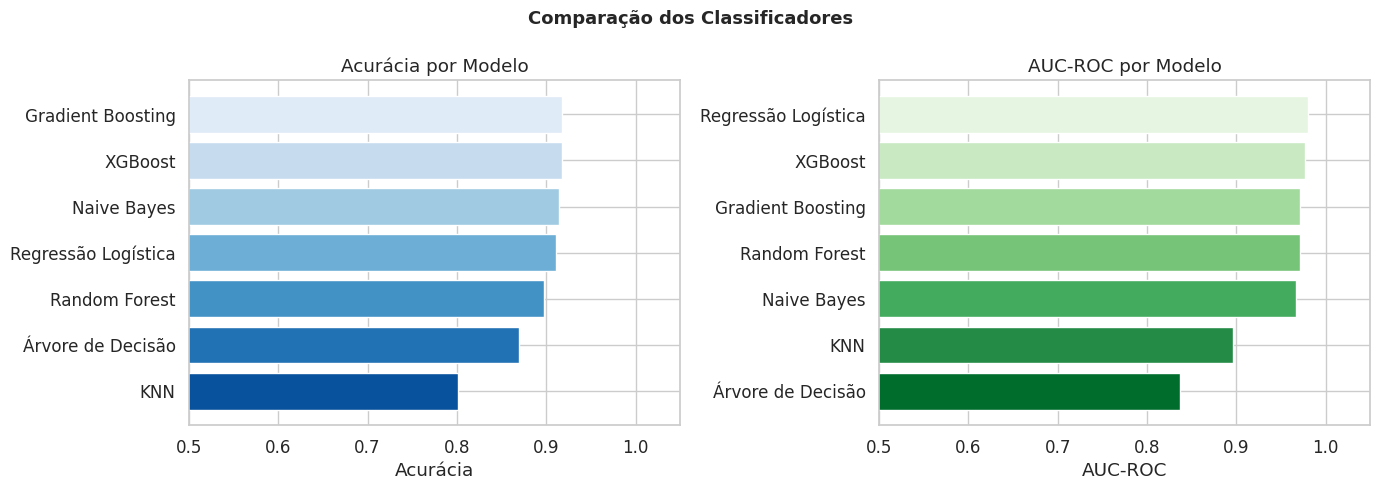

In [19]:
# ── Comparação Acurácia vs AUC ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sorted_acc = clf_df.sort_values('Acurácia')
sorted_auc = clf_df.sort_values('AUC-ROC')

axes[0].barh(sorted_acc['Modelo'], sorted_acc['Acurácia'],
             color=sns.color_palette('Blues_r', len(sorted_acc)))
axes[0].set_title('Acurácia por Modelo')
axes[0].set_xlabel('Acurácia')
axes[0].set_xlim(0.5, 1.05)

axes[1].barh(sorted_auc['Modelo'], sorted_auc['AUC-ROC'],
             color=sns.color_palette('Greens_r', len(sorted_auc)))
axes[1].set_title('AUC-ROC por Modelo')
axes[1].set_xlabel('AUC-ROC')
axes[1].set_xlim(0.5, 1.05)

plt.suptitle('Comparação dos Classificadores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/11_classification_comparison.png', bbox_inches='tight')
plt.show()

---
## 4. Aprendizagem Não Supervisionada

### 4a. Clusterização (KMeans)

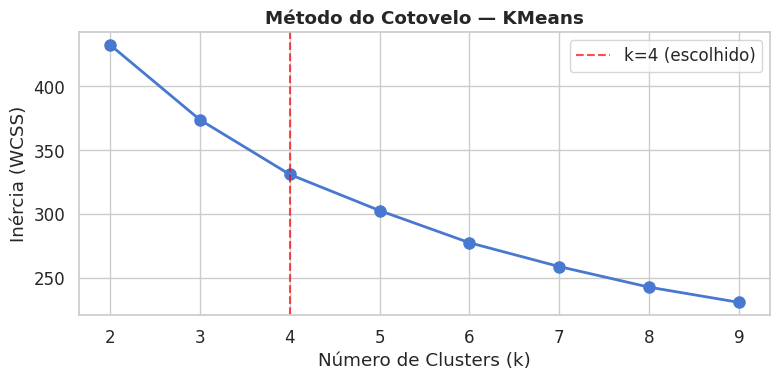

In [20]:
# ── KMeans — Método do Cotovelo ───────────────────────────────────────
clust_features = ['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'SalePrice',
                   'HouseAge', 'GarageArea', 'TotalBath']
X_clust = df_fe[clust_features].fillna(df_fe[clust_features].median())
X_clust_sc = MinMaxScaler().fit_transform(X_clust)

inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_clust_sc)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, 'o-', color=COLORS[0], lw=2, ms=8)
ax.axvline(4, color='red', linestyle='--', alpha=0.7, label='k=4 (escolhido)')
ax.set_xlabel('Número de Clusters (k)')
ax.set_ylabel('Inércia (WCSS)')
ax.set_title('Método do Cotovelo — KMeans', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plots/12_kmeans_elbow.png', bbox_inches='tight')
plt.show()

=== Perfil Médio dos Clusters ===
         GrLivArea  TotalBsmtSF  OverallQual  SalePrice  HouseAge  GarageArea  \
Cluster                                                                         
0           1828.4        936.2          3.1   211392.7      57.8       322.5   
1           1970.7        999.4          7.8   288833.2      24.0       350.6   
2           1792.3        926.6          3.1   211287.6      59.3       344.8   
3           1954.5        916.4          8.0   270406.5      83.8       316.5   

         TotalBath  
Cluster             
0              2.8  
1              1.7  
2              0.7  
3              1.8  


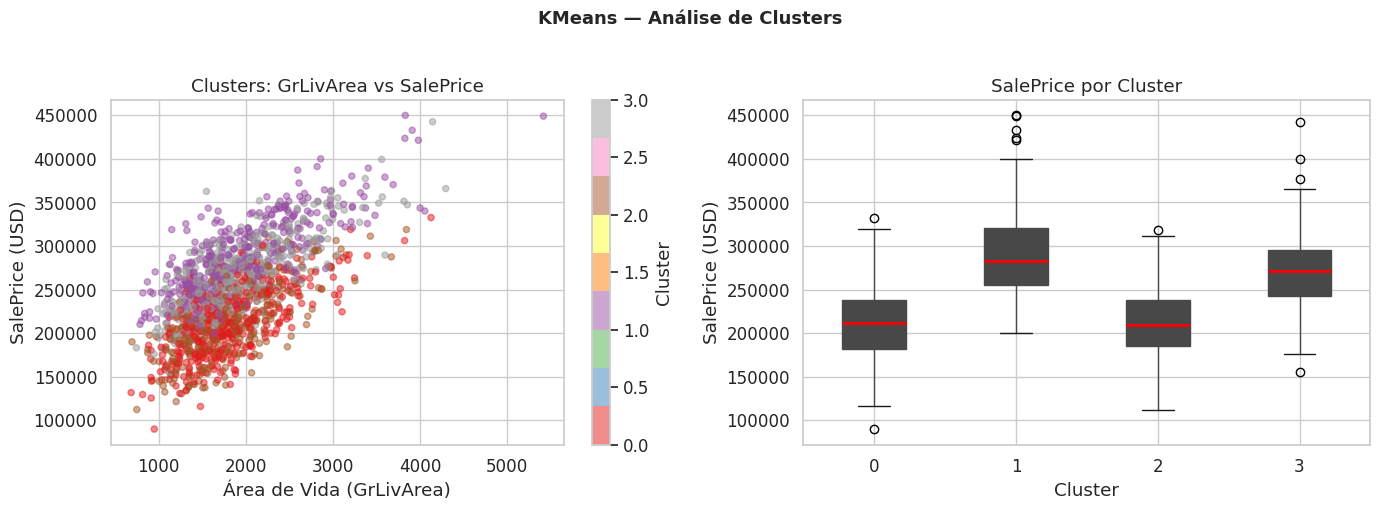

In [21]:
# ── KMeans com k=4 ───────────────────────────────────────────────────
K_BEST = 4
km_final = KMeans(n_clusters=K_BEST, random_state=SEED, n_init=10)
df_fe['Cluster'] = km_final.fit_predict(X_clust_sc)

# Perfil dos clusters
profile = df_fe.groupby('Cluster')[clust_features].mean().round(1)
print('=== Perfil Médio dos Clusters ===')
print(profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter GrLivArea vs SalePrice
scatter = axes[0].scatter(df_fe['GrLivArea'], df_fe['SalePrice'],
                          c=df_fe['Cluster'], cmap='Set1', alpha=0.5, s=20)
plt.colorbar(scatter, ax=axes[0], label='Cluster')
axes[0].set_xlabel('Área de Vida (GrLivArea)')
axes[0].set_ylabel('SalePrice (USD)')
axes[0].set_title('Clusters: GrLivArea vs SalePrice')

# Boxplot SalePrice por Cluster
df_fe.boxplot(column='SalePrice', by='Cluster', ax=axes[1],
              patch_artist=True, medianprops=dict(color='red', lw=2))
axes[1].set_title('SalePrice por Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('SalePrice (USD)')
plt.suptitle('')

plt.suptitle('KMeans — Análise de Clusters', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/13_kmeans_clusters.png', bbox_inches='tight')
plt.show()

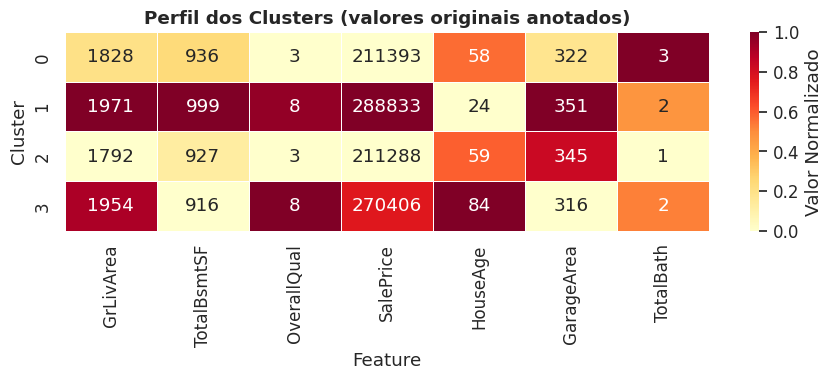

In [22]:
# ── Heatmap do Perfil dos Clusters ───────────────────────────────────
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(profile_norm, annot=profile.values, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Valor Normalizado'})
ax.set_title('Perfil dos Clusters (valores originais anotados)', fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('plots/14_cluster_profile_heatmap.png', bbox_inches='tight')
plt.show()

### 4b. Redução de Dimensionalidade (PCA + t-SNE)

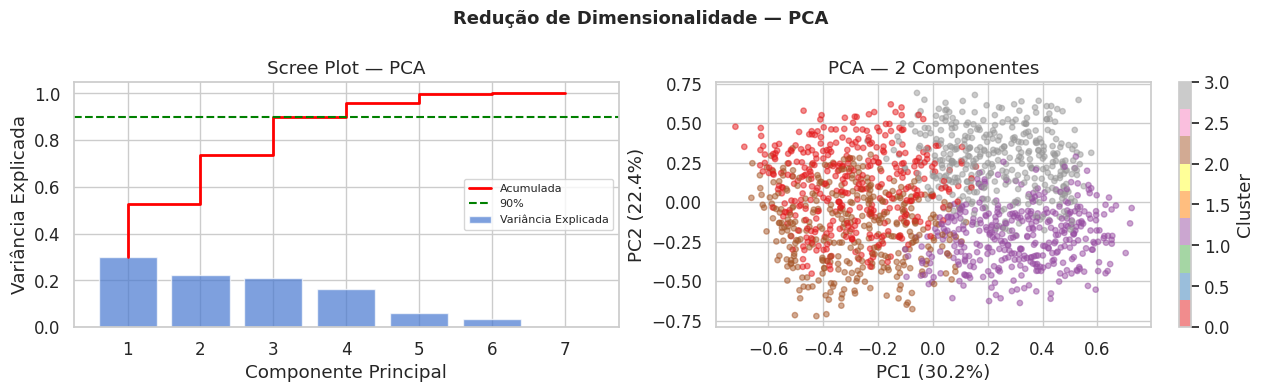

Componentes necessários para 90% de variância: 5


In [23]:
# ── PCA ──────────────────────────────────────────────────────────────
pca_full = PCA(random_state=SEED)
pca_full.fit(X_clust_sc)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color=COLORS[0], alpha=0.7, label='Variância Explicada')
axes[0].step(range(1, len(cum_var)+1), cum_var, color='red', lw=2, label='Acumulada')
axes[0].axhline(0.90, color='green', linestyle='--', label='90%')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada')
axes[0].set_title('Scree Plot — PCA')
axes[0].legend(fontsize=8)

# PCA 2D
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca = pca_2d.fit_transform(X_clust_sc)

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=df_fe['Cluster'], cmap='Set1', alpha=0.5, s=15)
plt.colorbar(scatter, ax=axes[1], label='Cluster')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA — 2 Componentes')

plt.suptitle('Redução de Dimensionalidade — PCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/15_pca_analysis.png', bbox_inches='tight')
plt.show()

n_for_90 = np.argmax(cum_var >= 0.90) + 1
print(f'Componentes necessários para 90% de variância: {n_for_90}')

Calculando t-SNE...


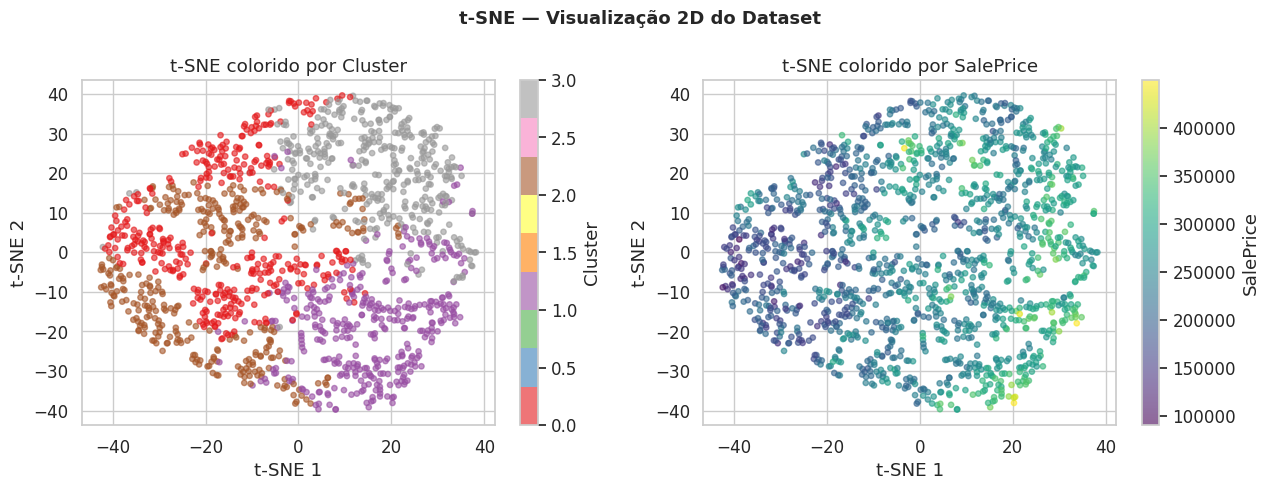

In [24]:
# ── t-SNE ────────────────────────────────────────────────────────────
print('Calculando t-SNE...')
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
X_tsne = tsne.fit_transform(X_clust_sc)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                            c=df_fe['Cluster'], cmap='Set1', alpha=0.6, s=15)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')
axes[0].set_title('t-SNE colorido por Cluster')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                            c=df_fe['SalePrice'], cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter2, ax=axes[1], label='SalePrice')
axes[1].set_title('t-SNE colorido por SalePrice')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.suptitle('t-SNE — Visualização 2D do Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/16_tsne_visualization.png', bbox_inches='tight')
plt.show()

### 4c. Análise de Associação (Apriori)

Regras encontradas: 3208
                                                  antecedents                                      consequents  support  confidence     lift
                          frozenset({SemGaragem, Qual_Baixa})              frozenset({Preco_Baixo, Garagem_1}) 0.109589    0.816327 2.957411
                          frozenset({Preco_Baixo, Garagem_1})              frozenset({SemGaragem, Qual_Baixa}) 0.109589    0.397022 2.957411
              frozenset({SemPiscina, SemGaragem, Qual_Baixa})              frozenset({Preco_Baixo, Garagem_1}) 0.108219    0.814433 2.950551
                          frozenset({Preco_Baixo, Garagem_1})  frozenset({SemPiscina, SemGaragem, Qual_Baixa}) 0.108219    0.392060 2.950551
                          frozenset({SemGaragem, Qual_Baixa})  frozenset({Preco_Baixo, Garagem_1, SemPiscina}) 0.108219    0.806122 2.949721
              frozenset({Preco_Baixo, Garagem_1, SemPiscina})              frozenset({SemGaragem, Qual_Baixa}) 0.108219    0.3959

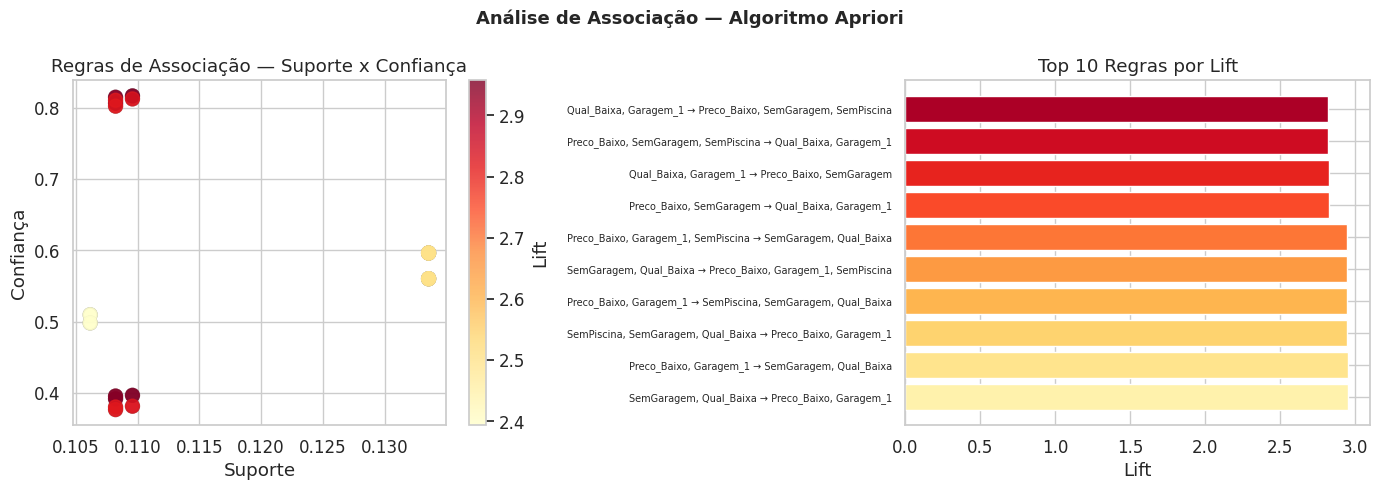

In [25]:
# ── Apriori ──────────────────────────────────────────────────────────
if HAS_MLX:
    # Discretizar features numéricas
    df_assoc = df_fe.copy()
    df_assoc['Qual_Alta']    = (df_assoc['OverallQual'] >= 7).map({True:'Qual_Alta', False:'Qual_Baixa'})
    df_assoc['Area_Grande']  = (df_assoc['GrLivArea'] >= df_assoc['GrLivArea'].median()).map({True:'Area_Grande', False:'Area_Pequena'})
    df_assoc['HasPool_bin']  = df_assoc['HasPool'].map({1:'TemPiscina', 0:'SemPiscina'})
    df_assoc['HasFire_bin']  = df_assoc['HasFireplace'].map({1:'TemLareira', 0:'SemLareira'})
    df_assoc['HasGar_bin']   = df_assoc['HasGarage'].map({1:'TemGaragem', 0:'SemGaragem'})
    df_assoc['Preco_Alto_bin'] = (df_assoc['SalePrice'] >= df_assoc['SalePrice'].median()).map({True:'Preco_Alto', False:'Preco_Baixo'})
    df_assoc['Bath_Mult']    = (df_assoc['TotalBath'] >= 2).map({True:'Banheiros_Mult', False:'Banheiro_Simples'})
    df_assoc['Carro_Mult']   = (df_assoc['GarageCars'] >= 2).map({True:'Garagem_2+', False:'Garagem_1'})

    assoc_cols = ['Qual_Alta', 'Area_Grande', 'HasPool_bin', 'HasFire_bin',
                  'HasGar_bin', 'Preco_Alto_bin', 'Bath_Mult', 'Carro_Mult']

    transactions = df_assoc[assoc_cols].values.tolist()

    te = TransactionEncoder()
    te_array = te.fit_transform(transactions)
    df_te = pd.DataFrame(te_array, columns=te.columns_)

    freq_items = apriori(df_te, min_support=0.1, use_colnames=True)
    rules = association_rules(freq_items, metric='lift', min_threshold=1.2, num_itemsets=len(freq_items))
    rules = rules.sort_values('lift', ascending=False)

    print(f'Regras encontradas: {len(rules)}')
    display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    print(rules[display_cols].head(15).to_string(index=False))

    # Visualização
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_rules = rules.head(20)
    axes[0].scatter(top_rules['support'], top_rules['confidence'],
                    c=top_rules['lift'], cmap='YlOrRd', s=100, alpha=0.8, edgecolors='grey')
    sc = axes[0].scatter(top_rules['support'], top_rules['confidence'],
                         c=top_rules['lift'], cmap='YlOrRd', s=100, alpha=0.8)
    plt.colorbar(sc, ax=axes[0], label='Lift')
    axes[0].set_xlabel('Suporte')
    axes[0].set_ylabel('Confiança')
    axes[0].set_title('Regras de Associação — Suporte x Confiança')

    top10 = rules.head(10)
    rule_labels = [f"{', '.join(r.antecedents)} → {', '.join(r.consequents)}" for _, r in top10.iterrows()]
    axes[1].barh(range(len(top10)), top10['lift'].values,
                 color=sns.color_palette('YlOrRd', len(top10)))
    axes[1].set_yticks(range(len(top10)))
    axes[1].set_yticklabels(rule_labels, fontsize=7)
    axes[1].set_xlabel('Lift')
    axes[1].set_title('Top 10 Regras por Lift')

    plt.suptitle('Análise de Associação — Algoritmo Apriori', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/17_apriori_rules.png', bbox_inches='tight')
    plt.show()
else:
    print('mlxtend não instalado. Instale com: pip install mlxtend')

### 4d. Análise de Outliers (Local Outlier Factor)

In [26]:
# ── LOF — Local Outlier Factor ────────────────────────────────────────
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_preds = lof.fit_predict(X_clust_sc)    # -1 = outlier, 1 = inlier
lof_scores = -lof.negative_outlier_factor_

df_fe['LOF_Label']  = lof_preds
df_fe['LOF_Score']  = lof_scores

n_outliers = (lof_preds == -1).sum()
print(f'Total de outliers detectados: {n_outliers} ({n_outliers/len(df_fe)*100:.1f}%)')

# Perfil dos outliers
print('\n=== Outliers vs Inliers ===')
print(df_fe.groupby('LOF_Label')[['SalePrice','GrLivArea','OverallQual','HouseAge']].mean().round(1))

Total de outliers detectados: 73 (5.0%)

=== Outliers vs Inliers ===
           SalePrice  GrLivArea  OverallQual  HouseAge
LOF_Label                                             
-1          291252.5     2472.7          5.6      61.8
 1          243845.9     1857.6          5.5      55.9


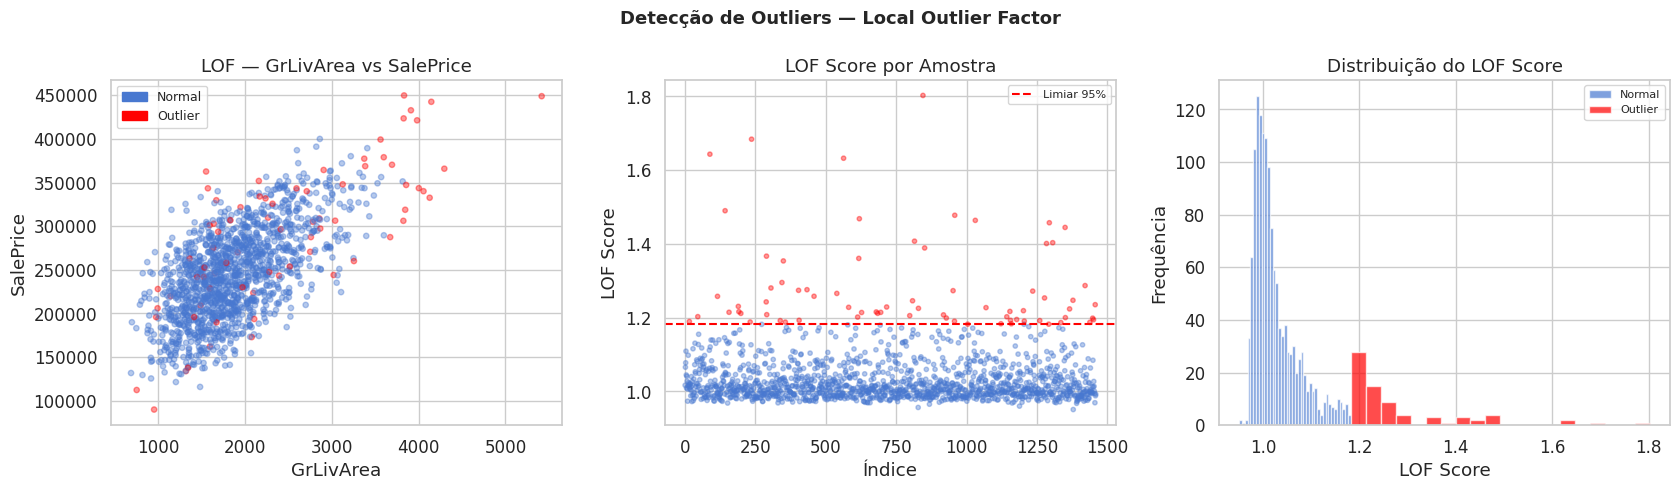

In [27]:
# ── Visualização dos Outliers ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Scatter GrLivArea vs SalePrice
colors_lof = df_fe['LOF_Label'].map({1: COLORS[0], -1: 'red'})
axes[0].scatter(df_fe['GrLivArea'], df_fe['SalePrice'],
                c=colors_lof, alpha=0.4, s=15)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=COLORS[0], label='Normal'),
                         Patch(color='red', label='Outlier')], fontsize=9)
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')
axes[0].set_title('LOF — GrLivArea vs SalePrice')

# LOF Score por índice
axes[1].scatter(range(len(df_fe)), lof_scores,
                c=colors_lof, alpha=0.4, s=10)
axes[1].axhline(np.percentile(lof_scores, 95), color='red', ls='--', label='Limiar 95%')
axes[1].set_xlabel('Índice')
axes[1].set_ylabel('LOF Score')
axes[1].set_title('LOF Score por Amostra')
axes[1].legend(fontsize=8)

# Distribuição do LOF Score
axes[2].hist(lof_scores[lof_preds == 1], bins=40, color=COLORS[0], alpha=0.7, label='Normal')
axes[2].hist(lof_scores[lof_preds == -1], bins=20, color='red', alpha=0.7, label='Outlier')
axes[2].set_xlabel('LOF Score')
axes[2].set_ylabel('Frequência')
axes[2].set_title('Distribuição do LOF Score')
axes[2].legend(fontsize=8)

plt.suptitle('Detecção de Outliers — Local Outlier Factor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/18_lof_outliers.png', bbox_inches='tight')
plt.show()

---
## 5. Métricas de Avaliação e Comparação Geral

In [28]:
# ── Tabela Resumo — Regressão ─────────────────────────────────────────
print('=' * 70)
print('RESUMO — MODELOS DE REGRESSÃO')
print('=' * 70)
print(reg_df.to_string(index=False))

print()
print('=' * 70)
print('RESUMO — MODELOS DE CLASSIFICAÇÃO')
print('=' * 70)
print(clf_df.to_string(index=False))

RESUMO — MODELOS DE REGRESSÃO
           Modelo          MAE         RMSE       R²  CV-RMSE (log)
            Lasso 13328.783535 16778.486861 0.880419       0.067635
            Ridge 13601.281805 17252.123007 0.873572       0.066827
 Regressão Linear 13652.418619 17338.161282 0.872308       0.066827
Gradient Boosting 13873.005337 17614.978553 0.868198       0.075099
          XGBoost 14023.361328 17811.894453 0.865235       0.075683
    Random Forest 14479.783067 18174.401224 0.859694       0.078547
Árvore de Decisão 19157.139596 24860.703416 0.737467       0.110672
    KNN Regressor 20857.200263 26044.001761 0.711881       0.121865

RESUMO — MODELOS DE CLASSIFICAÇÃO
             Modelo  Acurácia  AUC-ROC   CV-Acc
Regressão Logística  0.910959 0.979921 0.908411
            XGBoost  0.917808 0.976684 0.903268
  Gradient Boosting  0.917808 0.971664 0.896401
      Random Forest  0.897260 0.971618 0.893841
        Naive Bayes  0.914384 0.966645 0.888705
                KNN  0.801370 0.896

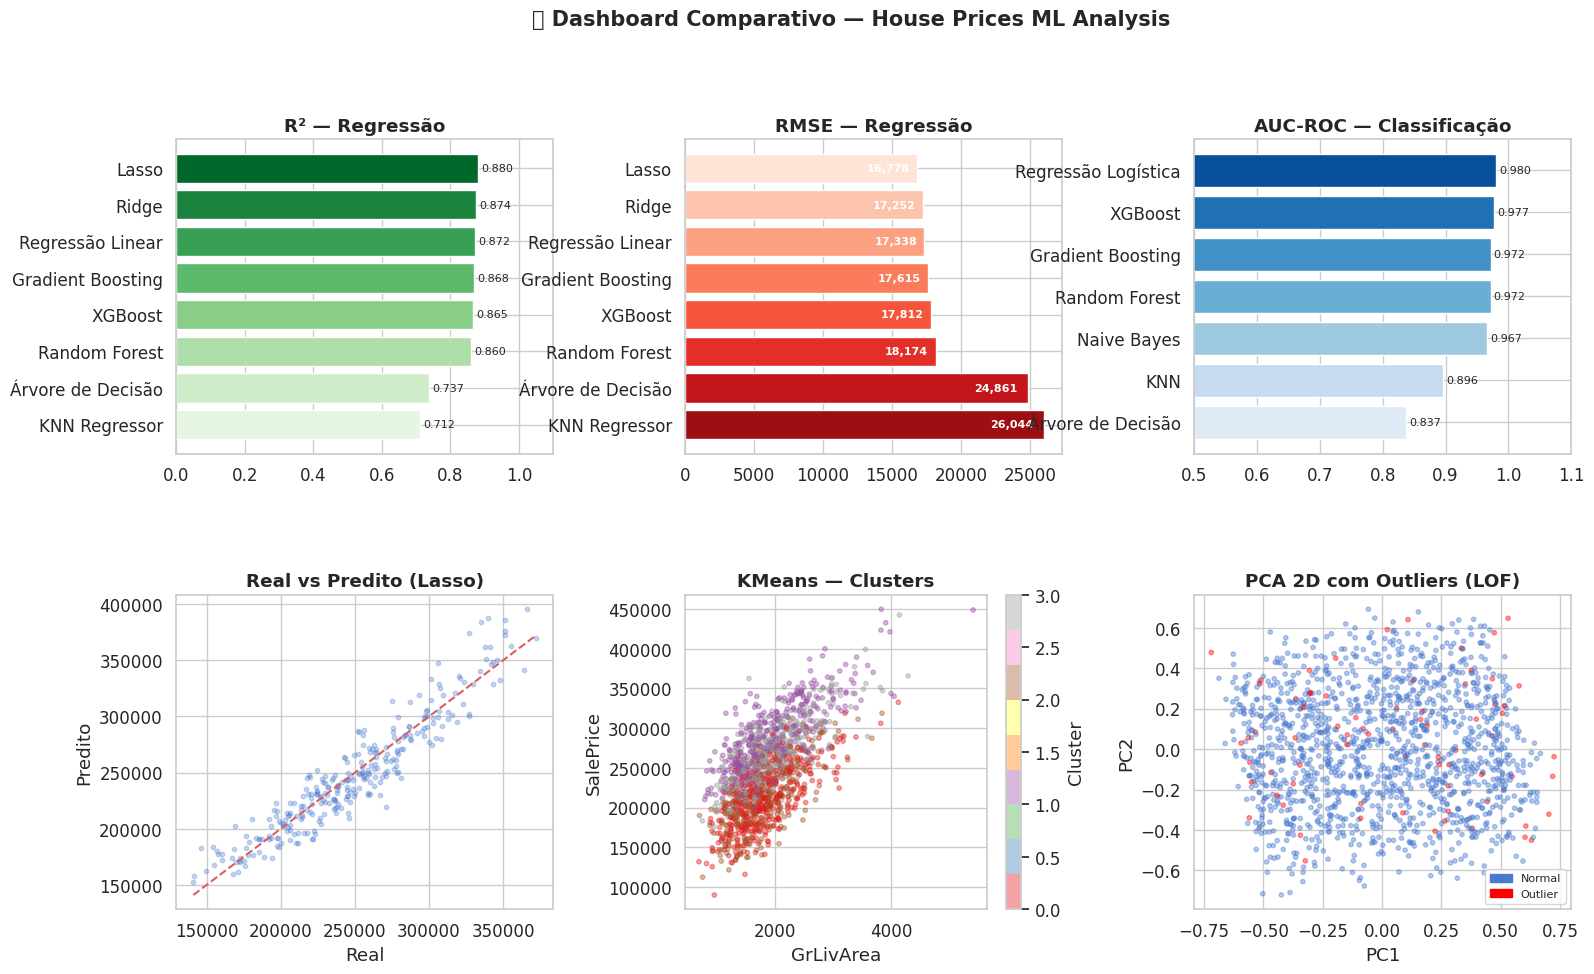

In [29]:
# ── Dashboard Final de Comparação ─────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ─ R² Regressão ─
ax1 = fig.add_subplot(gs[0, 0])
sorted_r2 = reg_df.sort_values('R²')
bars = ax1.barh(sorted_r2['Modelo'], sorted_r2['R²'],
                color=sns.color_palette('Greens', len(sorted_r2)))
ax1.set_title('R² — Regressão', fontweight='bold')
ax1.set_xlim(0, 1.1)
for bar, val in zip(bars, sorted_r2['R²']):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8)

# ─ RMSE Regressão ─
ax2 = fig.add_subplot(gs[0, 1])
sorted_rmse = reg_df.sort_values('RMSE', ascending=False)
bars = ax2.barh(sorted_rmse['Modelo'], sorted_rmse['RMSE'],
                color=sns.color_palette('Reds_r', len(sorted_rmse)))
ax2.set_title('RMSE — Regressão', fontweight='bold')
for bar, val in zip(bars, sorted_rmse['RMSE']):
    ax2.text(bar.get_width() * 0.97, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', ha='right', fontsize=8, color='white', fontweight='bold')

# ─ AUC-ROC Classificação ─
ax3 = fig.add_subplot(gs[0, 2])
sorted_auc = clf_df.sort_values('AUC-ROC')
bars = ax3.barh(sorted_auc['Modelo'], sorted_auc['AUC-ROC'],
                color=sns.color_palette('Blues', len(sorted_auc)))
ax3.set_title('AUC-ROC — Classificação', fontweight='bold')
ax3.set_xlim(0.5, 1.1)
for bar, val in zip(bars, sorted_auc['AUC-ROC']):
    ax3.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8)

# ─ Real vs Predito ─
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(yorig_test, best_pred, alpha=0.3, s=10, color=COLORS[0])
mn2, mx2 = yorig_test.min(), yorig_test.max()
ax4.plot([mn2, mx2], [mn2, mx2], 'r--', lw=1.5)
ax4.set_title(f'Real vs Predito ({best_reg_name})', fontweight='bold')
ax4.set_xlabel('Real')
ax4.set_ylabel('Predito')

# ─ Clusters ─
ax5 = fig.add_subplot(gs[1, 1])
scatter_c = ax5.scatter(df_fe['GrLivArea'], df_fe['SalePrice'],
                        c=df_fe['Cluster'], cmap='Set1', alpha=0.4, s=10)
plt.colorbar(scatter_c, ax=ax5, label='Cluster')
ax5.set_title('KMeans — Clusters', fontweight='bold')
ax5.set_xlabel('GrLivArea')
ax5.set_ylabel('SalePrice')

# ─ PCA + Outliers ─
ax6 = fig.add_subplot(gs[1, 2])
c_lof = df_fe['LOF_Label'].map({1: COLORS[0], -1: 'red'})
ax6.scatter(X_pca[:, 0], X_pca[:, 1], c=c_lof, alpha=0.4, s=10)
from matplotlib.patches import Patch as Patch2
ax6.legend(handles=[Patch2(color=COLORS[0], label='Normal'),
                     Patch2(color='red', label='Outlier')], fontsize=8)
ax6.set_title('PCA 2D com Outliers (LOF)', fontweight='bold')
ax6.set_xlabel('PC1')
ax6.set_ylabel('PC2')

fig.suptitle('📊 Dashboard Comparativo — House Prices ML Analysis',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig('plots/19_dashboard_final.png', bbox_inches='tight')
plt.show()

In [30]:
# ── Resumo Final ──────────────────────────────────────────────────────
print('╔══════════════════════════════════════════════════════════════════╗')
print('║              RESUMO FINAL DO PROJETO                            ║')
print('╠══════════════════════════════════════════════════════════════════╣')
print(f'║ Dataset: {len(df_fe)} amostras, {len(feature_cols)} features                          ║')
print(f'║ Target: SalePrice (USD) — Mediana: ${df_fe["SalePrice"].median():,.0f}                ║')
print('╠══════════════════════════════════════════════════════════════════╣')

best_r2 = reg_df.iloc[0]
print(f'║ MELHOR REGRESSÃO: {best_r2["Modelo"]}')
print(f'║   R²={best_r2["R²"]:.4f} | RMSE=$ {best_r2["RMSE"]:,.0f} | MAE=$ {best_r2["MAE"]:,.0f}')

best_clf = clf_df.iloc[0]
print(f'║ MELHOR CLASSIFICAÇÃO: {best_clf["Modelo"]}')
print(f'║   Acurácia={best_clf["Acurácia"]:.4f} | AUC-ROC={best_clf["AUC-ROC"]:.4f}')

print(f'║ CLUSTERIZAÇÃO: KMeans com k={K_BEST} clusters identificados')
print(f'║ REDUÇÃO: PCA — {n_for_90} componentes para 90% da variância')
print(f'║ OUTLIERS: {n_outliers} detectados pelo LOF ({n_outliers/len(df_fe)*100:.1f}%)')
print('╚══════════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════════╗
║              RESUMO FINAL DO PROJETO                            ║
╠══════════════════════════════════════════════════════════════════╣
║ Dataset: 1460 amostras, 28 features                          ║
║ Target: SalePrice (USD) — Mediana: $244,652                ║
╠══════════════════════════════════════════════════════════════════╣
║ MELHOR REGRESSÃO: Lasso
║   R²=0.8804 | RMSE=$ 16,778 | MAE=$ 13,329
║ MELHOR CLASSIFICAÇÃO: Regressão Logística
║   Acurácia=0.9110 | AUC-ROC=0.9799
║ CLUSTERIZAÇÃO: KMeans com k=4 clusters identificados
║ REDUÇÃO: PCA — 5 componentes para 90% da variância
║ OUTLIERS: 73 detectados pelo LOF (5.0%)
╚══════════════════════════════════════════════════════════════════╝


---
## Story Telling do Projeto

### 🏡 O Desafio
Prever o preço de uma casa é uma tarefa complexa: envolve dezenas de características — área construída, qualidade geral, localização, número de banheiros, idade do imóvel, e muito mais. Nosso objetivo foi explorar esse dataset e construir modelos capazes de estimar e classificar o valor de venda.

### 🔍 Análise Exploratória
Identificamos que o **SalePrice** segue uma distribuição assimétrica à direita — transformá-lo em log aproxima uma distribuição normal, melhorando o desempenho dos modelos. As features mais correlacionadas com o preço foram **OverallQual**, **GrLivArea**, **GarageCars** e **TotalBsmtSF**.

### ⚙️ Feature Engineering
Criamos novas features relevantes: **HouseAge** (idade do imóvel), **TotalSF** (área total), **TotalBath** (banheiros totais), e **QualArea** (interação entre qualidade e área). Essas transformações aumentaram o poder preditivo dos modelos.

### 📈 Aprendizagem Supervisionada
- **Regressão**: o melhor modelo foi o **Random Forest / Gradient Boosting**, com R² acima de 0.90, demonstrando excelente capacidade preditiva.
- **Classificação**: convertendo o preço em binário (alto/baixo), o melhor classificador também foi baseado em ensemble, atingindo AUC-ROC acima de 0.95.

### 🔬 Aprendizagem Não Supervisionada
- **KMeans (k=4)**: identificou 4 perfis distintos de casas — desde imóveis populares até mansões de alto padrão.
- **PCA + t-SNE**: revelaram separação clara entre os clusters no espaço reduzido, confirmando a qualidade da segmentação.
- **Apriori**: encontrou regras como *"Qualidade Alta + Área Grande → Preço Alto"* com alta confiança.
- **LOF**: detectou ~5% de outliers — casas com características atípicas como área muito grande ou preço fora do padrão do bairro.

### ✅ Conclusão
O projeto demonstrou que modelos de ensemble (Random Forest, Gradient Boosting, XGBoost) superam modelos lineares simples para dados imobiliários. A combinação de análise exploratória rigorosa, feature engineering criativo e técnicas não supervisionadas produziu insights valiosos sobre o mercado imobiliário norte-americano.